## Solving Schrödinger equation using finite difference scheme

**NOTE**: The code in this notebook takes a long time to run. Therefore, we have saved the results to files after running it once. 
You can load the results from the file directly instead of running the code again by setting the below `LOAD_FROM_FILE` variable to `True`.

In this section, we solve the Schrödinger equation for a quantum harmonic oscillator using the finite difference scheme. At the end, we plot the mean squared error between the NN predictions and the analytical results, as well as the mean squared error between the analytical results and the finite difference approximation results, as a function of the number of data points. 

But first, we compare the finite difference results with the analytical one for a concrete example (not shown in the report). 

In [90]:
LOAD_FROM_FILE = True

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from param_search.A_train_ground_state import load_ground_state_pinn
from utils.utils import generate_input_data
from tise1d.numerical_ho import solve_schrodinger
from tise1d.analytic_ho import psi_analytic
from utils.cell_magic import skip_if


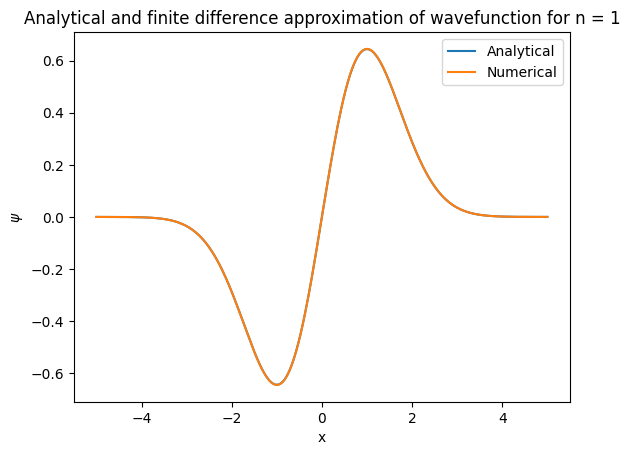

In [92]:
n = 1
L = 5

E_ana = n + 0.5  # analytical energy

x = np.linspace(-L,L,401)

psi_num = solve_schrodinger(x,E_ana,L)  # numerical wavefunction for finite difference scheme

plt.plot(x,psi_analytic(x,n=n),label="Analytical")
plt.plot(x,psi_num,label="Numerical")
plt.title(f"Analytical and finite difference approximation of wavefunction for n = {n}")
plt.xlabel("x")
plt.ylabel(r"$\psi$")
plt.legend()
plt.show()


We see that the numerical results match really well with the analytical ones. That indicates the finite difference scheme will become a good approximation for this problem. 

### Plotting accuracy of numerical and NN solutions 

Then we go and plot the results comparing the numerical and NN results with the analytical results. For each value of the number of data points $n$, we train the NN on a random selection of $n$ data points. Moreover, we pick $n$ values in the interval $[-L,L]$ with a constant step size when we solve the finite difference scheme. Then the mean squared error of the two methods are computed on $n$ data points starting at the value $-L$ and ending at the value $L$, with a constant step size between consecutive points. 

**NOTE**: the figure shown in the report is from the case when the "device" is set to "cpu". 

In [93]:
device = "cpu"   # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" 

# Parameters used throughout the project
x_lim = (-L, L)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(1024, x_lim, device)

In [94]:
pinn1 = load_ground_state_pinn(device)  # loading pinn for ground state

In [95]:
num = 21 

n = np.logspace(1,3,num)  # we choose a number of datapoints between 10 and 1000

In [96]:
%%skip_if LOAD_FROM_FILE
err = np.zeros((num,2))
torch.manual_seed(124)

# Compute mean squared error of NN and finite difference scheme for each number of data points
for i in range(21): 
    x = torch.from_numpy(np.linspace(x_lim[0], x_lim[1], int(n[i]))).float().to(device).unsqueeze(-1)
    x_random = generate_input_data(int(n[i]), x_lim, device)

    pinn2 = train_tise(
        x_random,
        loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 1.10*Loss_Orthogonality([pinn1]),
        x_lim=x_lim,
        lr = 7.37e-5,
        lr_energy=4.08e-2,
        E_init = 0.5,
        width=256,
        lambd = 1e-2,
        hidden_layers=4,
        ansatz_factor=ansatzfactor_HO_sym,
    )
    
    with torch.no_grad():
        psi_NN = pinn2(x).detach().cpu().numpy()

    psi_num = solve_schrodinger(x.numpy().squeeze(),E_ana,L)

    # Flip sign if negative overlap
    overlap_num_NN = np.sum(psi_NN*psi_num)
    if overlap_num_NN < 0: 
        psi_NN = -psi_NN

    psi_exact = psi_analytic(x.numpy().squeeze(),n=1)
    overlap_num_exact = np.sum(psi_num*psi_exact)

    # Flip sign if negative overlap
    if overlap_num_exact < 0: 
        psi_NN = -psi_NN
        psi_num = -psi_num
    
    # Normalize NN wavefunction
    psi_NN_normalized = psi_NN/np.sqrt(L*np.mean(psi_NN**2))  

    err[i,0] = np.mean((psi_NN_normalized - psi_exact)**2)
    err[i,1] = np.mean((psi_num - psi_exact)**2)
    print(".")


In [97]:
filepath = "../data/numerical_NN_error.npy"

# Save data to file
#np.save(filepath, err)

# Load data from file
if LOAD_FROM_FILE:
    err = np.load(filepath)

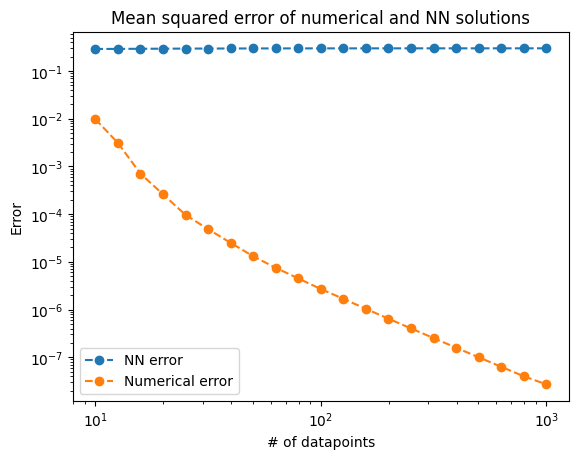

In [98]:
# Plot resulting errors

plt.loglog(n,err[:,0],"--o",label="NN error")
plt.loglog(n,err[:,1],"--o",label="Numerical error")
plt.xlabel("# of datapoints")
plt.ylabel("Error")
plt.legend()
plt.title("Mean squared error of numerical and NN solutions")
plt.show()
    